# Optimization 3 - Gradient descent in action

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 Partial Differentiation

### 1.1 Multivariate Calculus

#### One-Dimensional Function

$y = f(x)$ is a one-dimensional function that maps a single independent input variable $x$ to a single output value $y$.

#### Multi-Dimensional Function

$y = f(x_1, x_2, \ldots, x_n)$ is a multi-dimensional function that maps a multiple independent input variables $x_1, x_2, \ldots, x_n$ to a single output value $y$.

> **Note**:
>
> In both One-dimensional and Multi-dimensional Functions produces single output.

The **Loss Function** we are trying to minimize is a **multidimensional function** (or multi-variable function).

#### Derivatives of Multi-Dimensional Function

Derivatives of Multi-Dimensional Function is calculated using Partial Differentiation.

### 1.2 Partial Derivatives

#### What is Partial Derivatives?

Given a multi-variate function, process of calculating the derivative of that function w.r.t one variable at a time, considering all other variables as constant.

#### How to compute Partial Derivative?

**Q**: How to Calculate Partial Derivative of $f(x_1, x_2)$?

**Ans**:  
Partial derivatives of a multi-variable function $f(x_1, x_2)$ is represented as: 

$$
\large
\begin{aligned}
\frac{\partial}{\partial{x_1}} f(x_1, x_2) \\[12pt]
\frac{\partial}{\partial{x_2}} f(x_1, x_2)
\end{aligned}
$$

- Calculate derivative of $f(x_1, x_2)$ by changing $x_1$ and keeping $x_2$ as constant.
- Calculate derivative of $f(x_1, x_2)$ by changing $x_2$ and keeping $x_1$ as constant.

#### In ML Context

Given a Binary classification problem with below classifier (for example with two features) :

$$
\large
\begin{aligned}
w_1 x_1 + w_2 x_2 + w_0 = 0
\end{aligned}
$$

Partial derivative for $f(D, w_1, w_2, w_0)$

$$
\large
\begin{aligned}
\frac{\partial}{\partial{w_1}} f(w_1, w_2, w_0) \\[10pt]
\frac{\partial}{\partial{w_2}} f(w_1, w_2, w_0) \\[10pt]
\frac{\partial}{\partial{w_0}} f(w_1, w_2, w_0) \\[10pt]
\end{aligned}
$$

> **Note**:
>
> The last derivative i.e., $\partial_{w_0} f(w_1, w_2, w_0)$ will always be equal to 1.

#### Partial Derivative of a general function

Formula to calculate Partial derivative of any general function $f(x, y)$ with two variables $\{x, y\}$

$$
\large
\begin{aligned}
\frac{\partial}{\partial{x}} f(x, y) &= \lim_{\Delta{x}\;\to\;0} \frac{f(x + \Delta{x},\; y) - f(x, y)}{\Delta{x}} \\[20pt]
\frac{\partial}{\partial{y}} f(x, y) &= \lim_{\Delta{y}\;\to\;0} \frac{f(x,\; y + \Delta{y}) - f(x, y)}{\Delta{y}}
\end{aligned}
$$

#### Code

In [2]:
def partial_derivatives(func, x, y):
    """
    Function to calculate the partial derivatives of
    given function `func` w.r.t variables `x` and `y`.
    """
    delta = 0.001

    df_dx = (func(x + delta, y) - func(x, y)) / delta
    df_dy = (func(x, y + delta) - func(x, y)) / delta

    return round(df_dx, 6), round(df_dy, 6)

In [3]:
v1 = partial_derivatives(func=lambda x, y: x**2 + y**2, x=3, y=4)
print("Gradient vector:", v1)

Gradient vector: (6.001, 8.001)


In [4]:
v2 = partial_derivatives(func=lambda x, y: x**2 + y**2, x=1.3, y=1.5)
print("Gradient vector:", v2)

Gradient vector: (2.601, 3.001)


### 1.3 Gradient

#### Definition

The Partial Derivative of a multidimensional function represented in a vector form.

#### Properties

- In multivariate calculus the **slope of a tangent line** at any point (on a 3D shape for example) is called as **Gradient**.
- Since Gradient is a Vector it tells both direction and magnitude.

#### Gradient of a function

Given Binary Classifier having feature vector $\vec{x}$ of $d$ dimension and weight vector $\vec{w}$:

$$
\large
\begin{aligned}
f(w_1, w_2, \ldots, w_d, w_0) &= w_1 x_1 + w_2 x_2 + \ldots + w_d x_d + w_0 \\[5pt]
      f(\vec{w}, w_0) &= w_1 x_1 + w_2 x_2 + \ldots + w_d x_d + w_0
\end{aligned}
$$

Equation to calculate Gradient Vector for the above scalar function $f(\vec{w}, w_0)$

$$
\large
\begin{aligned}
\nabla_{\overrightarrow{w}, w_0} f(\vec{w}, w_0) = 
\begin{bmatrix} 
\displaystyle \frac{\partial}{\partial\;{w_1}} f(\vec{w}, w_0) \\[8pt]
\displaystyle \frac{\partial}{\partial\;{w_2}} f(\vec{w}, w_0) \\[8pt]
\vdots \\[5pt]
\displaystyle \frac{\partial}{\partial\;{w_d}} f(\vec{w}, w_0) \\[8pt]
\displaystyle \frac{\partial}{\partial\;{w_0}} f(\vec{w}, w_0)
\end{bmatrix}
\end{aligned}
$$

Visualize Gradient: https://www.desmos.com/3d/e3fratrwho

#### Example (In ML Context)

Given Binary classifier with two feature $\{ x_1, x_2\}$

$$
\large
\begin{aligned}
                      f(w_1, w_2, w_0) &= w_1 x_1 + w_2 x_2 + w_0 \\[5pt]
                                     z &= w_1 x_1 + w_2 x_2 + w_0 \\[15pt]
      \frac{\partial}{\partial{w_1}} z &= x_1 + 0 + 0 = x_1       \\[8pt]
      \frac{\partial}{\partial{w_2}} z &= 0 + x_2 + 0 = x_2       \\[8pt]
      \frac{\partial}{\partial{w_0}} z &= 0\;+0\; + 1 = 1         \\[15pt] 
\nabla_{\vec{w}, w_0} f(w_1, w_2, w_0) &= \begin{bmatrix} x_1 \\[3pt] x_2 \\[3pt] 1 \end{bmatrix}
\end{aligned}
$$

> **Note**:
>
> Gradient Vector after taking Partial Derivative of $\;w^T \cdot x\;$ w.r.t to $\vec{w}$, will always be its Feature Vector $\vec{x}$.

#### Significance of Gradient Vector

- The Gradient vector of a scalar function points in the direction of the steepest local ascent (maximum rate of increase) of the function.

### 1.4 Examples

#### Example 1

Calculate gradient of

$$
\large
\begin{aligned}
f(x, y) &= x^2 + 6xy + \log(y)
\end{aligned}
$$

##### Solution

Compute Partial derivative of $f(x, y)$ w.r.t $x$

$$
\large
\begin{aligned}
\frac{\partial}{\partial{x}} f(x, y) = 2x + 6y + 0 \\[10pt]
\boxed{\frac{\partial}{\partial{x}} f(x, y) = 2x + 6y}
\end{aligned}
$$

Compute Partial derivative of $f(x, y)$ w.r.t $y$

$$
\large
\begin{aligned}
\frac{\partial}{\partial{y}} f(x, y) = 0 + 6x + \frac{1}{y} \\[10pt]
\boxed{\displaystyle \frac{\partial}{\partial{y}} f(x, y) = 6x + \frac{1}{y}}
\end{aligned}
$$

Hence the equation of Gradient Vector:

$$
\large
\begin{aligned}
\nabla_{x,y} f(x, y) &= 
\begin{bmatrix} 
\displaystyle 2x + 6y \\[10pt] 
\displaystyle 6x + \frac{1}{y}
\end{bmatrix}
\end{aligned}
$$

#### Example 2

Calculate gradient of

$$
\large
\begin{aligned}
f(x, y) &= 3 \log (xy) + 4 y^2 x^3
\end{aligned}
$$

##### Solution

Compute Partial derivative of $f(x, y)$ w.r.t $x$

$$
\large
\begin{aligned}
\frac{\partial}{\partial{x}} f(x, y) = 3 \frac{1}{x\cancel{y}}\cancel{y} + (4y^2 \cdot 3x^2) \\[10pt]
\boxed{\frac{\partial}{\partial{x}} f(x, y) = \frac{3}{x} + 12 y^2 x^2}
\end{aligned}
$$

Compute Partial derivative of $f(x, y)$ w.r.t $y$

$$
\large
\begin{aligned}
\frac{\partial}{\partial{y}} f(x, y) = 3 \frac{1}{\cancel{x}{y}}\cancel{x} + (4 \cdot 2y \cdot x^3) \\[10pt]
\boxed{\frac{\partial}{\partial{y}} f(x, y) = \frac{3}{y} + 8y x^3}
\end{aligned}
$$

Hence the equation of Gradient Vector:

$$
\large
\begin{aligned}
\nabla_{x,y} f(x, y) = 
\begin{bmatrix} 
\displaystyle \frac{3}{x} + 12 y^2 x^2 \\[10pt] 
\displaystyle \frac{3}{y} + 8y x^3
\end{bmatrix}
\end{aligned}
$$

## 2 Gradient Descent

### 2.1 Gradient Descent Algorithm

#### Intuition for Gradient Descent

- In Gradient Descent the goal is to **reach minimum**.
- But a Gradient Vector always points in the direction of the steepest local ascent of the function.
- Hence the **negative of Gradient Vector** will point in **steepest local descent** (towards minima).

#### Gradient Update Rule

$$
\large
\begin{aligned}
w^n = w^o - \eta \frac{\partial}{\partial\;{w}} f(w^o)
\end{aligned}
$$

Where,

- $w$ - Gradient Vector
- $w^n$ - New $x$ values
- $w^o$ - Old $x$ values
- $\eta$ - Learning Rate

#### Learning Rate

- Learning rate $\eta$ is a Hyper-parameter that controls the step size of the descent.
- Too large value of $\eta$ can offshoot the descent.
- Too small values slows down the learning.
- Hence an optimal value must be decided by the end user.

#### Sudocode

- **STEP 1**: Initialize Gradient Vector $w$ with some random value.
- **STEP 2**: Initialize Learning Rate $\eta$ with some random small value.
- **STEP 3**: Repeat below **Gradient Update Rule** until convergence.
   - **STEP 3.1**: Compute new gradient vector by taking Partial Derivative of function $f(x)$ w.r.t $w$.
   - **STEP 3.2**: Multiply the new Gradient Vector with Learning Rate $\eta$.
   - **STEP 3.3**: Subtract old Gradient Vector $w^o$ with the new Gradient Vector from STEP 3.2.
   - **STEP 3.4**: Store the updated Gradient Vector from STEP 3.3 in $w^n$ (to be reused it in next iteration).

### 2.2 Implementation

Implementation of Gradient descent Algorithm in Python.

#### Derivative Function

In [5]:
def derivatives(func, x):
    """
    Function to calculate the derivative of given
    general function `func` w.r.t `x` vector.
    """
    delta = 0.0001
    df_dx = (func(x + delta) - func(x)) / delta

    return df_dx

#### Gradient Descent Algorithm

In [6]:
def gradient_descent(func, w_0=0, lr=0.01):
    """
    Function to apply Gradient Descent Algorithm on a given
    function `func` with initial value `w_0` and learning rate `lr`.
    """
    convergence = False
    w_log = [w_0]
    eta = lr
    max_iter = 10_000
    itr = 0

    while (not convergence) and (itr < max_iter):
        # Apply Gradient Update Rule.
        w_new = w_log[-1] - (eta * derivatives(func, w_log[-1]))

        # Check for convergence.
        if np.allclose(w_new, w_log[-1], rtol=1e-08, atol=1e-08):
            convergence = True

        w_log.append(w_new)
        itr += 1

    if itr == max_iter:
        raise ValueError("Max iteration reached. Try increasing learning rate.")

    return w_log

### 2.3 Examples

#### Example #1

Error Function: $f(x) = x^2 + 4x - 10$

In [7]:
def f(x):
    """
    Function representing Error Function:
    f(x) = x^2 + 4x - 10
    """
    return x**2 + (4 * x) - 10


f_vec = np.vectorize(f)

In [8]:
x = np.arange(-80, 80, 0.01)
y = f_vec(x)

Plot Error function $f(x) = x^2 + 4x - 10$

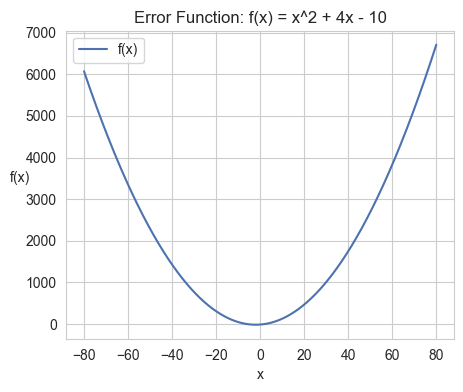

In [9]:
plt.figure(figsize=(5, 4))

sns.lineplot(x=x, y=y, label="f(x)")
plt.title("Error Function: f(x) = x^2 + 4x - 10")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)

plt.show()

GD in Action

In [10]:
w_log = gradient_descent(func=f, w_0=-50, lr=0.1)
itr_count = len(w_log)

print(f"Reached convergence in {itr_count} iterations.")
w_log[-3:]

Reached convergence in 90 iterations.


[-2.000050177856494, -2.000050142284948, -2.0000501138277116]

Plot Gradient Descent

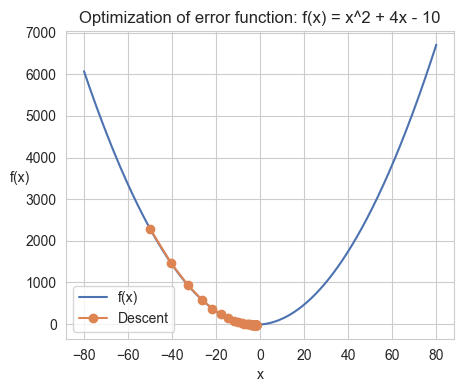

In [11]:
plt.figure(figsize=(5, 4))

# Plot Error Function.
sns.lineplot(x=x, y=y, label="f(x)")
plt.title("Optimization of error function: f(x) = x^2 + 4x - 10")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)

# Plot Descent to minima.
plt.plot(w_log, f_vec(w_log), marker="o", label="Descent")

plt.legend()
plt.show()

#### Example #2

Error Function: $f(x) = x^4 + 14x^2 + 24x + 10\sin(5x)$

In [12]:
def f(x):
    """
    Function representing Error Function:
    f(x) = x^4 + 14x^2 + 24x + 10sin(5x)
    """
    return x**4 - (14 * x**2) + (24 * x) + (10 * np.sin(5 * x).item())


f_vec = np.vectorize(f)

In [13]:
x = np.arange(-5, 4, 0.01)
y = f_vec(x)

Plot Error function $f(x) = x^4 + 14x^2 + 24x + 10\sin(5x)$

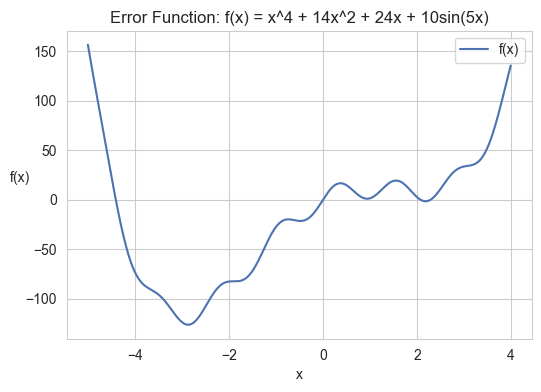

In [14]:
plt.figure(figsize=(6, 4))

sns.lineplot(x=x, y=y, label="f(x)")
plt.title("Error Function: f(x) = x^4 + 14x^2 + 24x + 10sin(5x)")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)

plt.show()

GD in Action

In [15]:
try:
    gradient_descent(func=f, lr=0.01)
except ValueError as e:
    print("ERROR:", e)

ERROR: Max iteration reached. Try increasing learning rate.


In [16]:
w_log = gradient_descent(func=f, lr=0.037)
itr_count = len(w_log)

print(f"Reached convergence in {itr_count} iterations.")
w_log[-2:]

Reached convergence in 24 iterations.


[-1.8842974698852863, -1.8842974941037092]

Plot Gradient Descent

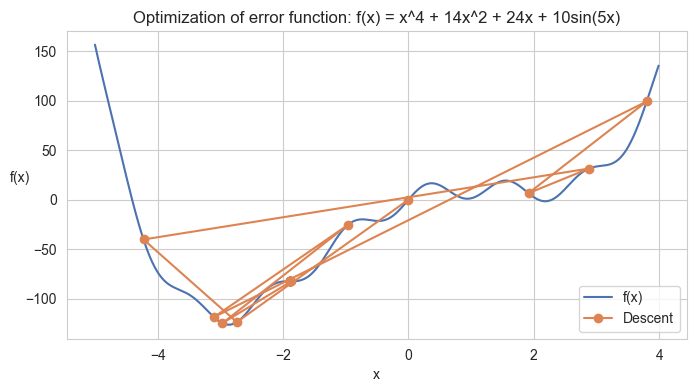

In [17]:
plt.figure(figsize=(8, 4))

# Plot Error Function.
sns.lineplot(x=x, y=y, label="f(x)")
plt.title("Optimization of error function: f(x) = x^4 + 14x^2 + 24x + 10sin(5x)")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)

# Plot Descent to minima.
plt.plot(w_log, f_vec(w_log), marker="o", label="Descent")

plt.legend()
plt.show()